Made by Jose Alan Barraza Villaverde

# PLM Control Guide
Complete workflow for controlling the DLP670S PLM.

**Important steps before running this notebook:** 
- Open the LightCrafter EVM GUI and verify that the connection is correct and is detecting the appropiate device.
- Close the LightCrafter EVM GUI before running this notebook – only one process can hold the USB connection.

In [1]:
import numpy as np
import ctypes
import matplotlib.pyplot as plt
from PLMController import PLMController
import time

## 1. Create Controller Instance
Adjust `MAX_FRAMES`, `N` (width), `M` (height), and the PLM monitor position `(x0, y0)` to match your setup.

In [2]:
MAX_FRAMES = 1
N = 1358   # PLM width
M = 800    # PLM height
# x0 and y0 control where the menu appears.
x0 = 2560
y0 = 0

dll_path = r'..\bin\plmctrl.dll'

plm = PLMController(MAX_FRAMES, N, M, dll_path, x0, y0)

## 2. Open USB Connection
Must be called **before** any configuration or display commands.

In [3]:
res = plm.open()
if res == 0:
    print(f"Open returned: {res}. The USB connection has been stablished successfully.")
else:
    print(f"Open returned: {res}. The USB connection has failed.")

Open returned: 0. The USB connection has been stablished successfully.


## 3. Start UI (Window)
`windowed=True` is useful for testing – it shows the PLM output in a resizable window.

In [4]:
plm.set_windowed(True)
plm.start_ui()

## 4. Configure the PLM
The `configure()` method runs the full setup sequence with proper delays:
- Set source to Parallel RGB (24-bit)
- Set port swap (ABC → ABC)
- Set connection type (HDMI or DisplayPort)
- Set video pattern mode
- Update lookup table

### Run this <span style="color: red;">**once per power cycle**</span> of the PLM.

In [5]:
source = 0 # Parallel RGB
port_width = 1
plm.set_source(source, port_width)
plm.set_port_swap(0,0)
# plm.set_port_swap(1,0) # Only use when working with Display Port
connection_type = 1 # 1 = HDMI, 2 = Display Port.
plm.set_pixel_mode(connection_type)
time.sleep(5) # It's important to pause between commands to setup the connection.
plm.set_connection_type(connection_type)
time.sleep(5)
plm.set_video_pattern_mode()
play_mode = 0 # 0 = Play Once, 1 = Continuous (Repeat mode)
plm.update_lut(play_mode, connection_type)

Setting pixel mode to HDMI
Setting connection to 1
Setting Video Pattern Mode
Updating bit lookup-table


## 5. Set Phase Map & Lookup Table
These define how the PLM maps grayscale values to phase levels.

- Phase Levels: Is a 17-element lookup table that maps continuous phase values (normalized 0 to 1, representing 0 to 2π) to 16 discrete quantization levels (0-15) for the PLM hardware plmctrl.cpp:157. It is used during the quantization step to determine which discrete level a continuous phase value belongs to plmctrl.cpp:931-941.

- Phase Map: Is a 16×4 lookup table (64 integers total) that maps each quantized phase level (0-15) to the specific binary state of the 4 sub-pixels that compose a single PLM logical pixel plmctrl.cpp:160-177. Each entry determines which bits are set for each sub-pixel during the bitpacking process plmctrl.cpp:972-975.

In [6]:
# Phase levels (voltage levels for the micromirrors)
phase_levels = np.array([0.000, 0.017, 0.036, 0.058, 0.085, 0.117, 0.157,
                         0.217, 0.296, 0.4, 0.5, 0.605, 0.713, 0.82,
                         0.922, 0.981, 1.0], dtype=np.float32)
plm.set_lookup_table(phase_levels)

# Phase map (which mirrors/voltages are active for each level)
phase_map = np.array([
    [0,0,0,0], [1,0,0,0], [0,1,0,0], [1,1,0,0],
    [0,0,1,0], [1,0,1,0], [0,1,1,0], [1,1,1,0],
    [0,0,0,1], [1,0,0,1], [0,1,0,1], [1,1,0,1],
    [0,0,1,1], [1,0,1,1], [0,1,1,1], [1,1,1,1],
], dtype=np.int32)
phase_map_order = (12, 8, 4, 14, 0, 6, 10, 2, 13, 5, 9, 1, 15, 7, 11, 3)
# This order of the states for phase delay is the one indicated in the manual.
phase_map = phase_map[phase_map_order, :]

plm.set_phase_map(phase_map)

1

## 6. Generate & Bitpack Holograms

### Method A: Bitpack and insert one frame at a time (simplest)

In [7]:
num_holograms = 24
phase = np.zeros((num_holograms, M, N), dtype=np.float32)
phase[:,:,N//2:] = phase_levels[11]
frame = plm.bitpack_holograms_gpu(phase)
plm.insert_frames(frame, offset=0, format=1)  # format 1 = RGBA
print(f"Inserted frame, shape={frame.shape}")

Inserted frame, shape=(1600, 10864)


### Method B: Bitpack and insert all at once (faster)

In [8]:
phase = np.zeros((M,N), dtype=np.float32)
phase[:, N//2:] = phase_levels[15]
phase = np.tile(phase[np.newaxis, :, :], (24,1,1))
  
# Bitpack and insert  
frame = plm.bitpack_holograms_gpu(phase)  
plm.insert_frames(frame, 0, format=1)
plm.set_frame(0)

## 7. Set Frame Sequence and Play

The frame sequence defines what order the inserted frames play in.

In [15]:
# Sequence of frame indices to play (length must equal MAX_FRAMES)
sequence = np.arange(MAX_FRAMES, dtype=np.uint64)
plm.set_frame_sequence(sequence)

In [16]:
# Start playback
plm.start_sequence(MAX_FRAMES)
print("Playing sequence - call plm.stop() to stop")

Playing sequence - call plm.stop() to stop


### Manual play/stop (alternative to start_sequence)

In [ ]:
# plm.play()
# import time; time.sleep(3)
# plm.stop()

## 8. Cleanup
Always run these cells to properly disconnect and release resources.

In [10]:
plm.stop()
plm.stop_ui()
plm.lib.Close()
print("Cleanup complete")

Cleanup complete


## 9. Visualize Phase Data (Debug)
Check what your phase patterns look like before sending to the PLM.

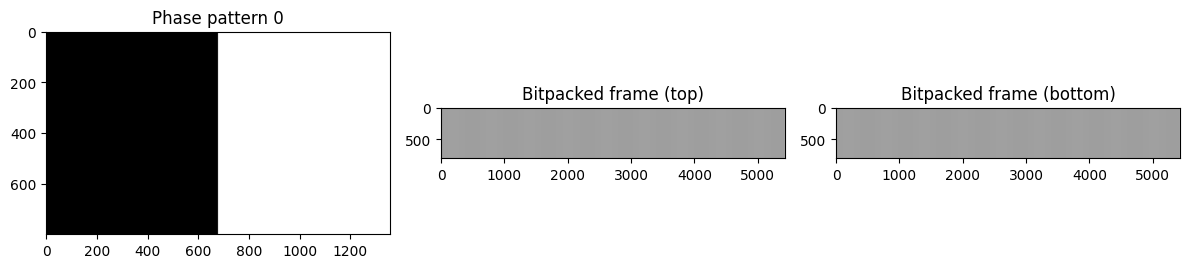

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(phase[0], cmap='gray')
plt.title("Phase pattern 0")
plt.subplot(1, 3, 2)
plt.imshow(frame[:M, :4*N], cmap='gray')
plt.title("Bitpacked frame (top)")
plt.subplot(1, 3, 3)
plt.imshow(frame[M:, :4*N], cmap='gray')
plt.title("Bitpacked frame (bottom)")
plt.tight_layout()
plt.show()

## Quick Reference

| Step | Method | Notes |
|------|--------|-------|
| Init | `PLMController(MAX_FRAMES, N, M, dll_path, x0, y0)` | |
| Window | `set_windowed(True)` then `start_ui()` | Windowed for testing |
| Connect | `open()` | Must come first |
| Config | `configure(play_mode, conn_type)` | Once per power cycle |
| Phase LUT | `set_lookup_table(levels)` | `float32` array |
| Phase map | `set_phase_map(map)` | `int32` 2D array |
| Bitpack | `bitpack_holograms_gpu(phase)` → frame | `float32` → `uint8` |
| Insert | `insert_frames(frame, offset, format)` | `format=1` for RGBA |
| Sequence | `set_frame_sequence(seq)` | `uint64` array |
| Play | `start_sequence(n)` or `play()` | |
| Stop | `stop()` | |
| Cleanup | `stop_ui()` then `lib.Close()` | |